In [43]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('dark_background' )
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.utils import to_categorical, plot_model
import os

In [44]:
import os
from PIL import Image
import numpy as np

data = []
result = []

folders = [
    (r"C:\Users\LOQ\OneDrive\Desktop\Deep Learning\Brain Tumor\brain_tumor_dataset\glioma", 0),
    (r"C:\Users\LOQ\OneDrive\Desktop\Deep Learning\Brain Tumor\brain_tumor_dataset\healthy", 1),
    (r"C:\Users\LOQ\OneDrive\Desktop\Deep Learning\Brain Tumor\brain_tumor_dataset\meningioma", 2),
    (r"C:\Users\LOQ\OneDrive\Desktop\Deep Learning\Brain Tumor\brain_tumor_dataset\pituitary", 3)
]

for folder_path, label in folders:
    for r, d, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                try:
                    path = os.path.join(r, file)

                    img = Image.open(path).convert('RGB')   # force 3 channels
                    img = img.resize((128, 128))
                    img = np.array(img) / 255.0            # normalization

                    if img.shape == (128, 128, 3):
                        data.append(img)
                        result.append(label)

                except:
                    continue  # skip corrupted images

# ✅ convert AFTER loop
data = np.array(data)
result = np.array(result)

# ✅ sanity check
print("Data shape:", data.shape)
print("Label shape:", result.shape)

Data shape: (7023, 128, 128, 3)
Label shape: (7023,)


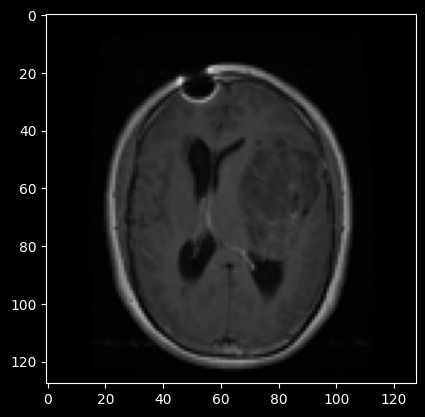

In [45]:
plt.imshow(data[5])

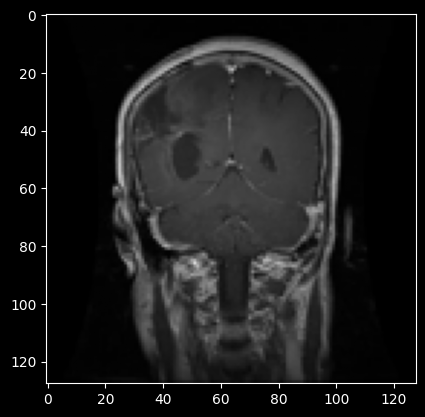

In [46]:
plt.imshow(data[400])

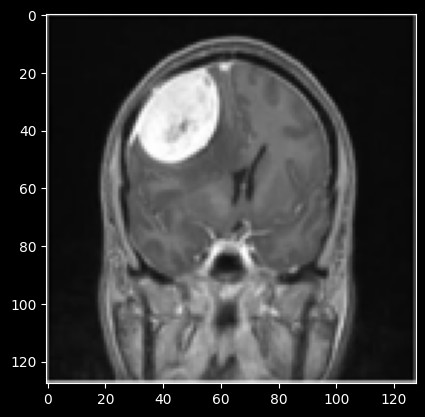

In [47]:
plt.imshow(data[5000])

In [48]:
x_train, x_test, y_train, y_test = train_test_split(
    data, result, test_size=0.2, shuffle=True, random_state=42
)

In [49]:
model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3), padding='same'))
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))
model.add(BatchNormalization())

# Block 2
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))
model.add(BatchNormalization())

# Block 3
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Dense
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

# Output
model.add(Dense(4, activation='softmax'))

print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,529,700 (32.54 MB)

 Trainable params: 8,529,508 (32.54 MB)

 Non-trainable params: 192 (768.00 B)

None


In [50]:
model.compile(loss="sparse_categorical_crossentropy",optimizer="adam",metrics=["accuracy"])

In [51]:
x_train.shape

(5618, 128, 128, 3)

In [52]:
y_train.shape

(5618,)

In [53]:
history = model.fit(x_train, y_train,epochs=10,batch_size=64,verbose=1,validation_data=(x_test, y_test))

Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.6266 - loss: 2.3623 - val_accuracy: 0.2448 - val_loss: 2.1286
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.7642 - loss: 0.5979 - val_accuracy: 0.2918 - val_loss: 2.6240
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.7921 - loss: 0.5147 - val_accuracy: 0.4342 - val_loss: 1.1656
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.8127 - loss: 0.4637 - val_accuracy: 0.7053 - val_loss: 0.7199
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.8238 - loss: 0.4267 - val_accuracy: 0.7117 - val_loss: 0.8116
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.8434 - loss: 0.4021 - val_accuracy: 0.8448 - val_loss: 0.4222
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.8405 - loss: 0.3984 - val_accuracy: 0.8555 - val_loss: 0.3499
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.8533 - loss: 0.3554 - val_accuracy: 0.8491 - v

In [54]:
score = model.evaluate(x_test, y_test, batch_size=64)
print("\nTest accuracy: %.1f%%" % (100.0 * score[1]))

22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 210ms/step - accuracy: 0.8975 - loss: 0.2618

Test accuracy: 89.8%


In [62]:
#manual prediction
img = Image.open(r"C:\Users\LOQ\OneDrive\Desktop\Deep Learning\Brain Tumor\brain_tumor_dataset\glioma\0352.jpg").convert('RGB')
img = img.resize((128, 128))
img_array = np.array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)  # add batch dimension
pred = model.predict(img_array)
predicted_class = np.argmax(pred)
if predicted_class == 0:
    print("Predicted: Glioma")
elif predicted_class == 1:
    print("Predicted: Healthy")
elif predicted_class == 2:
    print("Predicted: Meningioma")
elif predicted_class == 3:
    print("Predicted: Pituitary")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted: Glioma


In [ ]:
#Testing the model with a new images


classes = ["glioma", "healthy", "meningioma", "pituitary"]

# 🔹 PASTE YOUR IMAGE PATH HERE
img_path = r"C:\Users\LOQ\OneDrive\Desktop\Deep Learning\Brain Tumor\brain_tumor_dataset\Test\meningioma_tumor4.jpg"
# load image
img = Image.open(img_path).convert('RGB')
img = img.resize((128, 128))
img = np.array(img) / 255.0

# reshape
img = np.expand_dims(img, axis=0)

# predict
pred = model.predict(img, verbose=0)

class_index = np.argmax(pred)
confidence = np.max(pred)

# result
print("Prediction:", classes[class_index])
print("Confidence:", round(confidence * 100, 2), "%")

Prediction: meningioma
Confidence: 94.89 %


In [76]:
#Testing the model with a new images


classes = ["glioma", "healthy", "meningioma", "pituitary"]

# 🔹 PASTE YOUR IMAGE PATH HERE
img_path = r"C:\Users\LOQ\OneDrive\Desktop\Deep Learning\Brain Tumor\brain_tumor_dataset\Test\meningioma_tumor4.jpg"
# load image
img = Image.open(img_path).convert('RGB')
img = img.resize((128, 128))
img = np.array(img) / 255.0

# reshape
img = np.expand_dims(img, axis=0)

# predict
pred = model.predict(img, verbose=0)

class_index = np.argmax(pred)
confidence = np.max(pred)

# result
print("Prediction:", classes[class_index])
print("Confidence:", round(confidence * 100, 2), "%")

Prediction: meningioma
Confidence: 94.89 %


In [79]:
#save the model in the native Keras format
model.save('brain_tumor_model.h5')

# To this:
model.save('brain_tumor_model.keras')